In [297]:
from mypy import *

## 超参数

In [298]:
expo_time = r'7 ms'
power = r'25 $\rm mW$'
title = r'{}: {} (曝光时间: ' + expo_time + r'; 激光功率: ' + power + ')'

In [299]:
dir_spade = './test/s{}_{}.tif'

spade.point_1 = (162, 129)
spade.point_2 = (162, 416)

spade.characteristic_width = 103 / dmd.pixel_size

In [300]:
dir_di = './test/s{}_{}.tif'

di.zero_point = 171
di.pixel_size = qcmos.pixel_size / dmd.pixel_size
# di.pixel_size = 1

In [301]:
samples = 1000

In [302]:
# matplotlib_parameter.set_figsize(16, 4)
matplotlib_parameter.set_figsize(5, 5)

## Test DI

In [303]:
def di_s(j):
    di_s = []
    n = []
    for i in range(samples):
        img = imread(dir_di.format(j, i+1))
        di_s.append(di.estimator(img))
        n.append(di.photon_number(img))
    return np.array(di_s), np.array(n)

In [308]:
s = []
var = []
n = []
for i in range(-7, 8):
    temp = di_s(i)
    s.append(temp[0].mean())
    var.append(temp[0].var())
    n.append(temp[1].sum())

s = np.array(s)
var = np.array(var)
n = np.array(n)

n_var = np.sqrt(n/samples * var) 

axis = np.arange(-7, 8) / spade.characteristic_width

In [315]:
qcmos.grayscale_value_to_photon_number((n / samples).mean(), offset=0)

159034.45727809524

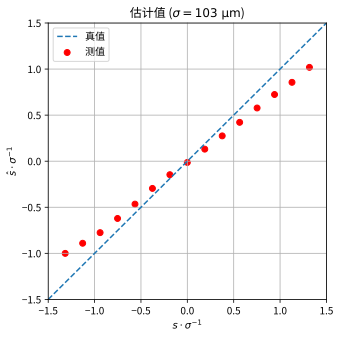

In [312]:
plot((-1.5, 1.5), lambda x: x, show=False, fmts='--', xlabel=r'$s\cdot\sigma^{-1}$', ylabel=r'$\hat s\cdot\sigma^{-1}$', label='真值', xlim=(-1.5, 1.5), ylim=(-1.5, 1.5))
scatter(axis, s / spade.characteristic_width, c='r', colorbar=False, title=r'估计值 ($\sigma = 103\ {\rm\mu m}$)', label='测值')


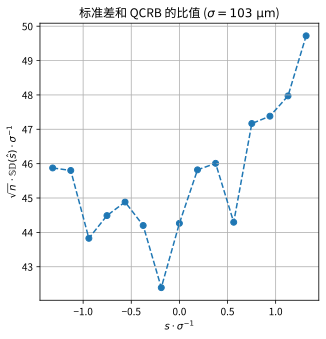

In [313]:
plot(axis, n_var, fmts='--', show=False, xlabel=r'$s\cdot\sigma^{-1}$', ylabel=r'$\sqrt{n}\cdot{\rm \mathbb{SD}}(\hat s)\cdot\sigma^{-1}$', )
scatter(axis, n_var, colorbar=False, title=r'标准差和 QCRB 的比值 ($\sigma = 103\ {\rm\mu m}$)')

In [306]:
raise

RuntimeError: No active exception to reraise

## Test

In [ ]:
def spade_s(j):
    spade_s = []
    p1 = []
    p2 = []
    for i in range(samples):
        img = imread(dir_spade.format(j, i+1))
        spade_s.append(spade.estimator(img, mode='+-'))
        p1.append(spade.photon_number(img)[0])
        p2.append(spade.photon_number(img)[1])
    return np.array(spade_s), np.array(p1), np.array(p2)

In [ ]:
s = []
var = []
p1 = []
p2 = []
for i in range(-7, 8):
    temp = spade_s(i)
    s.append(temp[0].mean())
    var.append(temp[0].var())
    p1.append(temp[1].sum())
    p2.append(temp[2].sum())

s = np.array(s)
var = np.array(var)
p1 = np.array(p1)
p2 = np.array(p2)
n = (p1+p2) / samples
n_var = np.sqrt(n*var) / spade.characteristic_width

axis = np.arange(-7, 8) / spade.characteristic_width

In [ ]:
plot((-1.5, 1.5), lambda x: x, show=False, fmts='--', xlabel=r'$s\cdot\sigma^{-1}$', ylabel=r'$\hat s\cdot\sigma^{-1}$', label='真值', xlim=(-1.5, 1.5), ylim=(-1.5, 1.5))
scatter(axis, s / spade.characteristic_width, c='r', colorbar=False, title=r'估计值 ($\sigma = 103\ {\rm\mu m}$)', label='测值')

In [ ]:
plot(axis, n_var, fmts='--', show=False, xlabel=r'$s\cdot\sigma^{-1}$', ylabel=r'$\sqrt{n}\cdot{\rm \mathbb{SD}}(\hat s)\cdot\sigma^{-1}$', )
scatter(axis, n_var, colorbar=False, title=r'标准差和 QCRB 的比值 ($\sigma = 103\ {\rm\mu m}$)')

In [ ]:
raise

## SPADE

In [ ]:
spade_s = []
p1 = []
p2 = []

for i in range(samples):
    img = imread(dir_spade.format(i+1))
    spade_s.append(spade.estimator(img, mode='+-'))
    p1.append(spade.photon_number(img)[0])
    p2.append(spade.photon_number(img)[1])

spade_s = np.array(spade_s)
p1 = np.array(p1)
p2 = np.array(p2)

In [ ]:
plot((1, samples), spade_s,
     xlabel='单位: 帧', ylabel='估计值 (单位: DMD 像素)', title=title.format('SPADE', '估计值'), 
     save='spade_s.svg')

In [ ]:
plot((1, samples), p1,
     xlabel='单位: 帧', ylabel='光子数 (单位: 灰度值)', title=title.format('SPADE', 'P-光子数'), 
     save='spade_p-_n.svg')

In [ ]:
plot((1, samples), p2,
     xlabel='单位: 帧', ylabel='光子数 (单位: 灰度值)', title=title.format('SPADE', 'P+光子数'), 
     save='spade_p+_n.svg')

In [ ]:
print('SPADE: ')

spade_mean = spade_s.mean()
print('均值: ' + str(spade_mean))

spade_var = spade_s.var()
print('方差: ' + str(spade_var))

spade_n = (p1+p2).sum() / samples
print('平均光子数: ' + str(spade_n) + ' (单位: 灰度)')

spade_n_var = spade_var * spade_n
print('平均光子数*方差: ' + str(spade_n_var) + ' (单位: 灰度)')


# qcmos.offset = 100
# print('用公式换算后的光子数: ' + str(qcmos.grayscale_value_to_photon_number(spade_n)) + ' (单位: 个)')

In [ ]:
print('和 QCRB 的比值: ' + str(sqrt(spade_n_var) / spade.characteristic_width))

In [ ]:
raise

## DI

In [ ]:
di_s = []
n = []
for i in range(samples):
    img = imread(dir_di.format(i+1))
    di_s.append(di.estimator(img))
    n.append(di.photon_number(img))

di_s = np.array(di_s)
n = np.array(n)

In [ ]:
plot((1, samples), di_s, 
     xlabel='单位: 帧', ylabel='估计值 (单位: DMD 像素)', title=title.format('DI', '估计值'), 
     save='di_s.svg')

In [ ]:
plot((1, samples), n, 
     xlabel='单位: 帧', ylabel='光子数 (单位: 灰度值)', title=title.format('DI', '单张图片的总光子数'), 
     save='di_n.svg')

In [ ]:
print('DI: ')

di_mean = di_s.mean()
print('均值: ' + str(di_mean))

di_var = di_s.var()
print('方差: ' + str(di_var))

di_n = n.sum() / samples
print('平均光子数: ' + str(di_n))

di_n_var = di_var * di_n
print('平均光子数*方差: ' + str(di_n_var))

## 数据汇总

In [ ]:
from IPython.display import Math

def x(num1, num2):
    return '{' + str(num1) + r'\times' + str(num2) + '}'

tex_var = r'\frac{{\rm Var}[s_{_{\rm SPADE}}]}{{{\rm Var}[s_{_{\rm DI}}]}}=\frac'
tex_nvar = r'\frac{N_{_{\rm SPADE}}\times{\rm Var}[s_{_{\rm SPADE}}]}{{N_{_{\rm DI}}\times{\rm Var}[s_{_{\rm DI}}]}}=\frac'

tex_var = tex_var + '{' + str(spade_var) + '}' + '{' + str(di_var) + '}' + '=' + str(spade_var / di_var)
tex_nvar = tex_nvar + x(spade_n, spade_var) + x(di_n, di_var) + '=' + str(spade_n_var / di_n_var)

In [ ]:
Math(tex_var)

In [ ]:
Math(tex_nvar)

## 自动生成实验报告模版

In [ ]:
import time, os

m, d = time.localtime()[1], time.localtime()[2]

if not os.path.exists('./{}.{}实验报告.md/'.format(m, d)):
    f = open('./{}.{}实验报告.md'.format(m, d), 'w')
    f.write('# {}.{} 实验报告\n'.format(m, d))
    f.write('## 前言\n')
    f.write('**激光功率: {}**\n'.format(power))
    f.write('**曝光时间: {}**\n'.format(expo_time))
    f.write('## 实验结果\n')
    f.write('**方差比值:**\n')
    f.write('\n $$ \n' + tex_var + '\n $$ \n')
    f.write('\n $$ \n' + tex_nvar + '\n $$ \n')
    f.write('**数据图:**\n')
    for line in ['![spade_s](./spade_s.svg)', '![spade_p-_n](./spade_p-_n.svg)', '![spade_p+_n](./spade_p+_n.svg)', 
                '![di_s](./di_s.svg)', '![di_n](./di_n.svg)']:
        f.write(line + '\n')
    f.close()